# 01 · Who should we email? — customer-level uplift  ⭐ ANCHOR A

**The decision.** We have a €10 discount and a customer list. Emailing everyone burns
margin on people who'd have bought anyway (and nudges some to unsubscribe); emailing no
one leaves money on the table. **Who, exactly, should get the offer?**

Every customer is one of four types, and only the treatment *effect* — not the outcome —
tells them apart:

| | buys if emailed | doesn't buy if emailed |
|---|---|---|
| **buys if not emailed** | 🟡 *Sure Thing* (τ≈0, wasted discount) | 🔴 *Sleeping Dog* (τ<0, email backfires) |
| **doesn't buy if not emailed** | 🟢 *Persuadable* (τ>0, the target) | ⚪ *Lost Cause* (τ≈0, no point) |

Targeting is worth doing **only because the effect is heterogeneous** — if everyone had
the same τ you'd rationally treat all or none. So the entire problem is estimating the
per-customer effect `τ(x)` well, and turning it into a euro decision under uncertainty.

This is the flagship notebook: the fixed **7-step contract**, then the **three depths** a
data scientist needs to defend the number.

- **Steps** 1 question → 2 simulate → 3 identify → 4 estimate → 5 validate → 6 decide in € → 7 caveats
- **Depth A** estimator bake-off & failure modes · **Depth B** identification rigour & sensitivity · **Depth C** euro policy, VOI & test design

> Narration is business-first. "Bayesian" stays in the background; credible intervals show
> up as *"how sure are we, and does it change what we'd do?"*


In [1]:
import os, warnings, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

from cmp import dgp, estimators as est, metrics, policy, plots
plots.use_style()

FAST = os.environ.get("CMP_FAST", "1") == "1"
SEED = 7
COST = 8.0                       # € cost of one discount contact
N    = 900 if FAST else 1600
PROF = dict(draws=140, tune=140, chains=2, m=30) if FAST else dict(draws=600, tune=600, chains=4, m=100)
rng  = np.random.default_rng(SEED)
print(f"FAST={FAST}  N={N}  sampling={PROF}")

FAST=True  N=900  sampling={'draws': 140, 'tune': 140, 'chains': 2, 'm': 30}


## 2 · Simulate a ground truth (validation-first)

We can't check a causal method on real data — the individual effect is never observed. So
we make the method **prove itself on data where we planted the answer**, then (with the
same code) swap in real data. Our simulator plants a known per-customer effect `τ(x)`,
a known baseline spend, and — crucially for the observational case — a **selection rule**:
historically marketers emailed the already-engaged, recently-active customers, so treatment
is *confounded* with the kind of customer.

The planted effect is deliberately realistic and **heterogeneous**: engaged mid-recency
customers are **persuadable** (large +τ); habitual high-frequency low-engagement customers
are **sleeping dogs** (τ<0, the email pushes them to unsubscribe); the rest sit near zero.

> **Swap in real data here.** Replace this cell with a loader returning the same columns;
> `cmp.data.load_hillstrom` gives a real *randomized* email experiment.


In [2]:
df = dgp.uplift_customers(n=N, regime="observational", confounder_strength=0.0, cost=COST, seed=SEED)
feat = df.attrs["feature_cols"]
X, T, y, tau = df[feat].values, df["T"].values, df["y"].values, df["tau"].values

# classify the four uplift types from the known truth (teaching only — unknown in practice)
types = np.where(tau > COST, "persuadable",
         np.where(tau < 0, "sleeping dog", "sure thing / lost cause"))
summary = pd.Series(types).value_counts(normalize=True).round(2)
print(f"True ATE = €{tau.mean():.2f}   ·   emailed historically: {T.mean():.0%} of base")
print("\nUplift types (share of base):")
print(summary.to_string())
df[feat + ['T','y','tau']].head()

True ATE = €6.07   ·   emailed historically: 47% of base

Uplift types (share of base):
sure thing / lost cause    0.39
persuadable                0.32
sleeping dog               0.29


,recency,frequency,monetary,tenure,engage,T,y,tau
0,208.156027,6.0,108.310843,13.737214,0.276899,0.0,42.175390,-0.457966
1,296.594485,3.0,142.587867,25.200485,0.473980,0.0,67.436225,-0.028135
2,257.097849,4.0,107.168786,57.141597,0.390539,0.0,48.743181,0.129894
3,78.192337,7.0,98.732666,13.421173,0.086593,0.0,46.782878,-9.869026
4,102.554043,7.0,87.199065,4.999605,0.359222,1.0,69.098355,21.912770


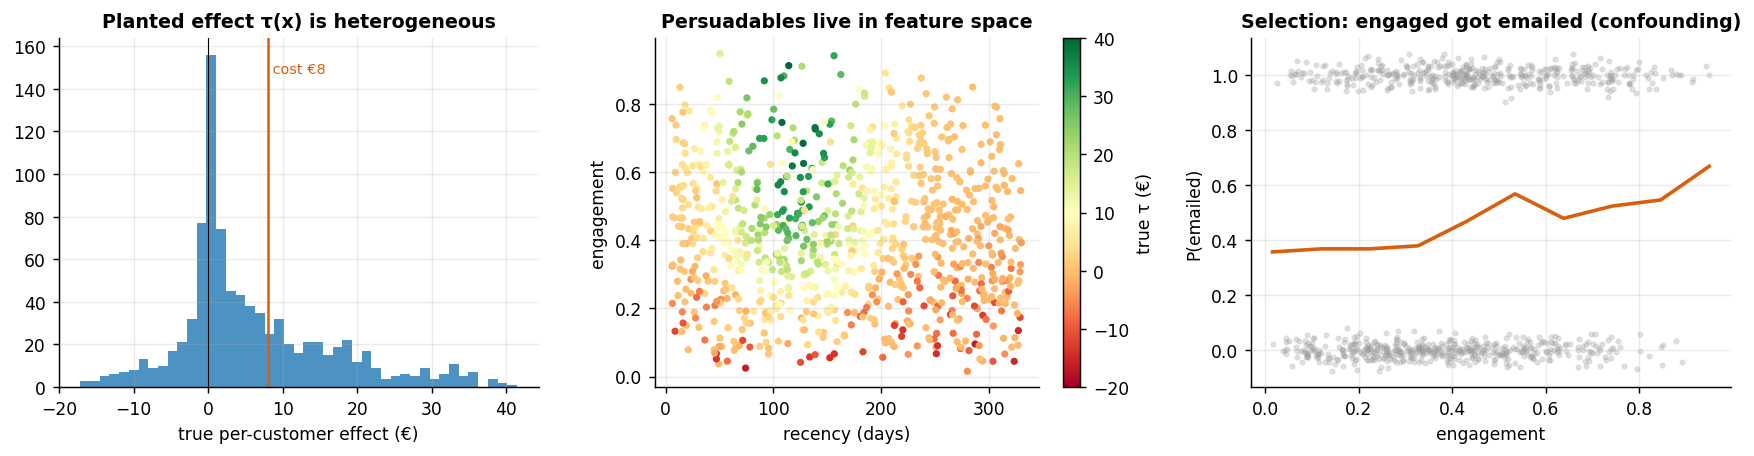

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.6))
ax[0].hist(tau, bins=45, color=plots.BLUE, alpha=0.85)
ax[0].axvline(COST, color=plots.ORANGE, lw=1.4); ax[0].axvline(0, color="k", lw=0.6)
ax[0].text(COST, ax[0].get_ylim()[1]*0.9, f" cost €{COST:.0f}", fontsize=8, color=plots.ORANGE)
ax[0].set_title("Planted effect τ(x) is heterogeneous"); ax[0].set_xlabel("true per-customer effect (€)")
sc = ax[1].scatter(df.recency, df.engage, c=tau, cmap="RdYlGn", s=9, vmin=-20, vmax=40)
ax[1].set_xlabel("recency (days)"); ax[1].set_ylabel("engagement"); ax[1].set_title("Persuadables live in feature space")
plt.colorbar(sc, ax=ax[1], label="true τ (€)")
# selection: who got emailed vs engagement — the confounding, made visible
ax[2].scatter(df.engage, df["T"] + rng.normal(0, 0.03, N), s=6, alpha=0.25, color=plots.GREY)
eng_bins = pd.qcut(df.engage, 10)
rate = df.groupby(eng_bins, observed=True)["T"].mean()
ax[2].plot(np.linspace(df.engage.min(), df.engage.max(), 10), rate.values, color=plots.ORANGE, lw=2)
ax[2].set_xlabel("engagement"); ax[2].set_ylabel("P(emailed)"); ax[2].set_title("Selection: engaged got emailed (confounding)")
fig.tight_layout()

## 3 · Identify — estimand and assumptions (kept separate from estimation)

**Estimand ladder** (three questions, three objects):

| object | definition | used for |
|---|---|---|
| **ATE** | $\mathbb{E}[Y(1)-Y(0)]$ | "does the campaign work at all?" |
| **CATE** $\tau(x)$ | $\mathbb{E}[Y(1)-Y(0)\mid X=x]$ | *who* to target |
| **policy value** | $\mathbb{E}[(Y(1)-Y(0)-c)\,\mathbb{1}\{\text{target }x\}]$ | euros from a targeting rule |

The uplift decision needs the whole ladder, but everything rests on `τ(x)=μ_1(x)-μ_0(x)`.

**Identification assumptions** (turn the estimand into something estimable):

1. **Unconfoundedness** $\{Y(1),Y(0)\}\perp T\mid X$ — given the features, who got emailed is
   as-good-as-random. *Holds by design under an A/B test; an assumption otherwise.* (Depth B)
2. **Positivity / overlap** $0<e(x)<1$, $e(x)=P(T{=}1\mid X{=}x)$. Checked before we trust any
   adjustment. (Depth B)
3. **SUTVA** — no spillover between customers, one version of the offer.

Under 1–3 the g-formula gives $\tau(x)=\mu_1(x)-\mu_0(x)$. **Identification is an assumption
about the world (untestable); estimation is where the model earns its keep — priors never
rescue a broken identification strategy.** The adjustment set is the DAG's backdoor set:


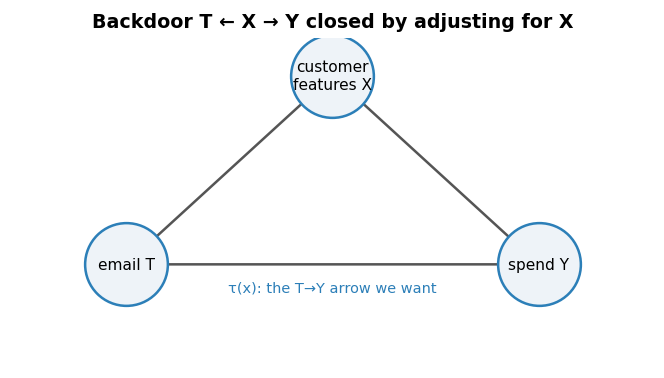

In [4]:
fig, ax = plt.subplots(figsize=(5.2, 3.0))
pos = {"customer\nfeatures X": (0.5, 1.0), "email T": (0.08, 0.25), "spend Y": (0.92, 0.25)}
edges = [("customer\nfeatures X","email T"),("customer\nfeatures X","spend Y"),("email T","spend Y")]
plots.draw_dag(ax, pos, edges, title="Backdoor T ← X → Y closed by adjusting for X")
ax.text(0.5, 0.14, "τ(x): the T→Y arrow we want", ha="center", fontsize=8, color=plots.BLUE); fig.tight_layout()

## 4 · Estimate — overlap first, then a posterior over each effect

Discipline: **check overlap before estimating**, because adjustment on regions with no
control (or no treated) is extrapolation dressed up as inference. Then we fit two ways and
cross-check:

- **BCF** (Bayesian Causal Forest) — flexible BART response surface with the estimated
  propensity fed into the *prognostic* part to absorb targeted-selection bias, and a
  tighter prior on the *treatment* part so heterogeneity shrinks toward homogeneity rather
  than being read out of noise. Our primary CATE estimator here.
- **AIPW** (augmented IPW) — a model-agnostic **doubly-robust** ATE: consistent if *either*
  the outcome model or the propensity model is right. A sanity check on the ATE that leans
  on completely different machinery than BART.

> **Baked-in gotcha.** Scoring BART counterfactuals silently returns *frozen* training
> predictions — every effect exactly 0 — unless the tree node is resampled
> (`sample_vars=["mu"]`). `cmp.estimators` always does this; a test asserts non-zero CATE.


overlap adequate — 0 of 900 units in the <0.05 / >0.95 tails


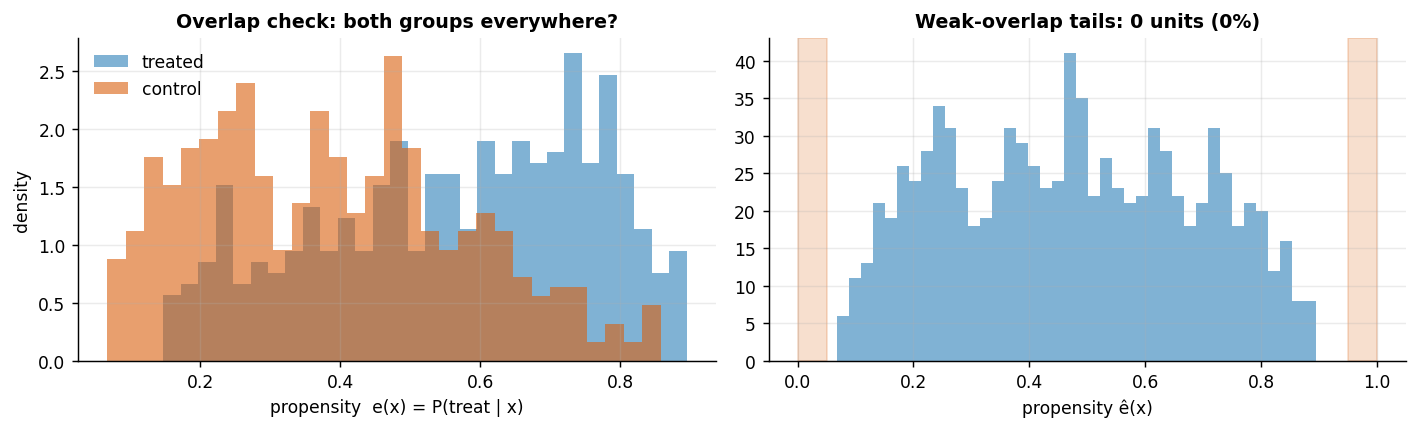

In [5]:
phat = est.propensity_scores(X, T, seed=SEED)     # ê(x)=P(email|x)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
plots.overlap_plot(ax[0], phat, T.astype(bool))
# trim check: how many units fall in weak-overlap tails?
weak = (phat < 0.05) | (phat > 0.95)
ax[1].hist(phat, bins=40, color=plots.BLUE, alpha=0.6); ax[1].axvspan(0, 0.05, color=plots.ORANGE, alpha=0.2)
ax[1].axvspan(0.95, 1.0, color=plots.ORANGE, alpha=0.2)
ax[1].set_xlabel("propensity ê(x)"); ax[1].set_title(f"Weak-overlap tails: {weak.sum()} units ({weak.mean():.0%})")
fig.tight_layout()
print(f"overlap adequate — {weak.sum()} of {N} units in the <0.05 / >0.95 tails")

In [6]:
# primary CATE estimator: BCF
cate_bcf = est.bcf(X, T, y, phat, seed=60, **PROF)          # (S, N) posterior CATE
cate_point = cate_bcf.mean(0)

# doubly-robust ATE cross-check (bootstrap distribution)
aipw = est.aipw_ate(X, T, y, seed=SEED, n_boot=200 if FAST else 500)

print(f"BCF   ATE = €{cate_bcf.mean():.2f}   (true €{tau.mean():.2f})")
print(f"AIPW  ATE = €{aipw['ate']:.2f}   90% CI [{aipw['ci90'][0]:.2f}, {aipw['ci90'][1]:.2f}]   "
      f"(doubly-robust, {aipw['n_trimmed']} trimmed)")
print("Two independent estimators agreeing on the ATE is our first credibility check.")

Multiprocess sampling (2 chains in 2 jobs)


CompoundStep


>CompoundStep


>>PGBART: [prog]


>>PGBART: [tau]


>NUTS: [sd]


Sampling 2 chains for 140 tune and 140 draw iterations (280 + 280 draws total) took 14 seconds.


BCF   ATE = €6.20   (true €6.07)
AIPW  ATE = €5.85   90% CI [5.19, 6.99]   (doubly-robust, 0 trimmed)
Two independent estimators agreeing on the ATE is our first credibility check.


**Model criticism — posterior predictive check.** Before reading effects off the model, ask
whether it can even reproduce the data it was fit on. We overlay observed spend against
posterior-predictive replicates; systematic misfit (wrong spread, missed skew) would warn us
the effect estimates aren't trustworthy.


Observed spend sits within the replicate envelope (residual σ ≈ €15) — no gross misfit.


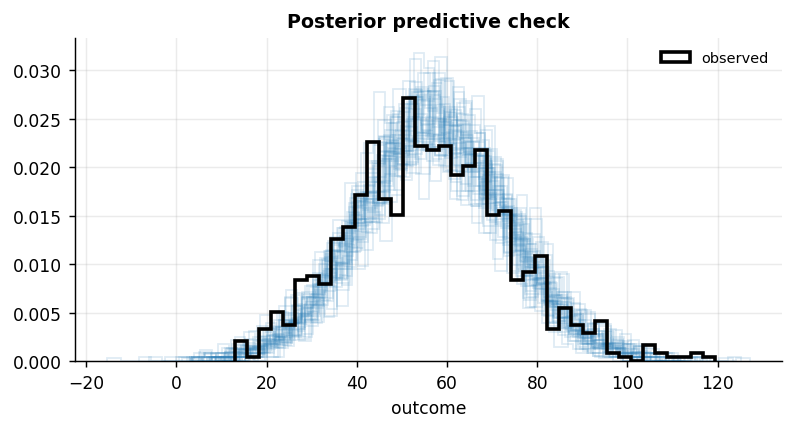

In [7]:
# Posterior-predictive replicates from the BCF fit: the fitted conditional mean is
# baseline + tau(x)*T; draw replicate spend at the posterior residual scale and compare
# the *distribution* of replicated spend to the observed one.
cond_mean = (y.mean() - cate_point.mean() * T.mean()) + cate_point * T   # baseline + tau*T
resid_sd = float(np.std(y - cond_mean))
y_rep = cond_mean[None, :] + rng.normal(0, resid_sd, size=(40, N))
fig, ax = plt.subplots(figsize=(6.2, 3.4))
plots.ppc_plot(ax, y, y_rep)
fig.tight_layout()
print(f"Observed spend sits within the replicate envelope (residual σ ≈ €{resid_sd:.0f}) — no gross misfit.")

## 5 · Validate — recover truth, honest uncertainty, and ranking quality

Because we planted the truth we can run the full validation battery. Three questions:

1. **Recovery & calibration** — does `τ̂(x)` track `τ(x)` (PEHE, correlation)? Do the
   credible intervals contain the truth ~90% of the time, *across the whole effect range*
   (coverage by decile), and are the *magnitudes* calibrated (reliability curve)? And are
   the intervals **sharp** enough to act on?
2. **Ranking quality** — for targeting, ordering customers correctly matters more than exact
   magnitudes. The **Qini/uplift curve** and **AUUC** measure exactly that, vs a random and
   an oracle policy. The **uplift-by-decile** staircase shows the top deciles really do have
   the biggest true effect.
3. **Stability** — is the recovery a fluke of one seed? We refit on several resimulations.


PEHE 6.37  ·  corr 0.84  ·  90% coverage 82%  ·  interval sharpness €14.6


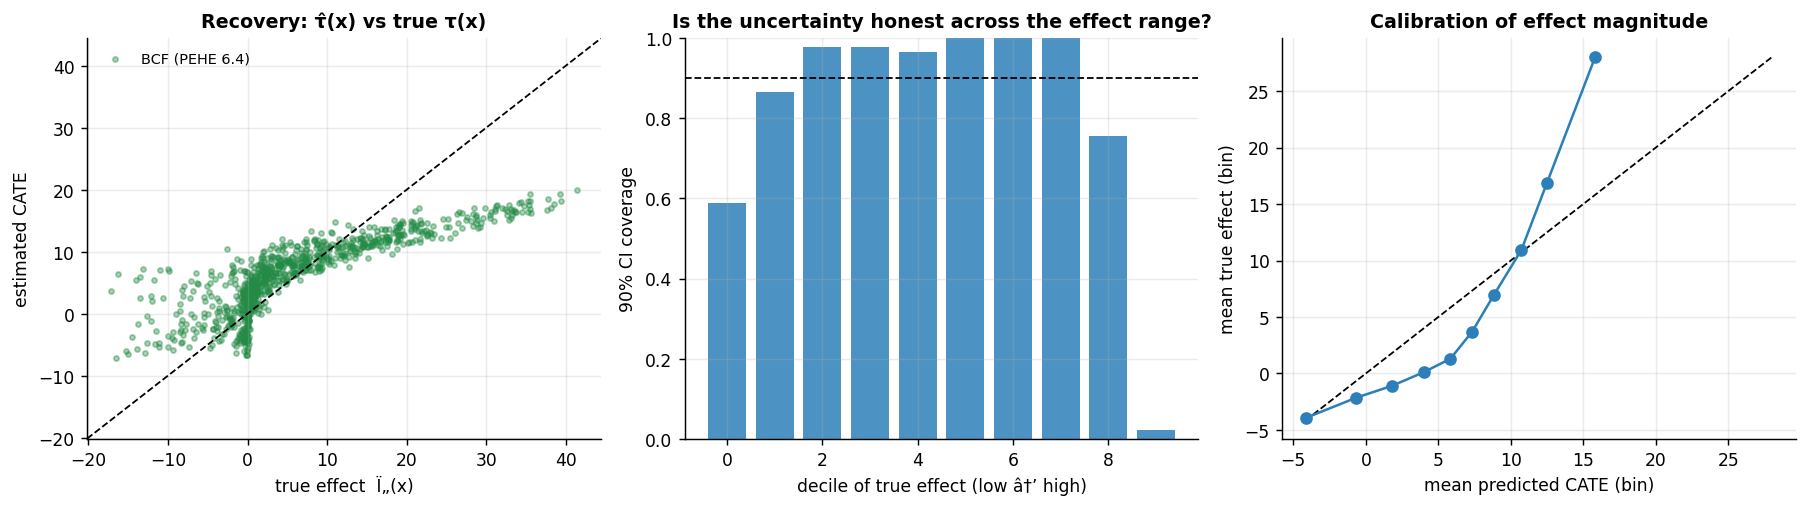

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
plots.recovery_scatter(ax[0], tau, {"BCF": cate_point}, title="Recovery: τ̂(x) vs true τ(x)")
cov, by_dec = metrics.interval_coverage(cate_bcf, tau, level=0.90, by_decile=True)
plots.calibration_by_decile(ax[1], by_dec, level=0.90)
pred_b, true_b = metrics.reliability_curve(cate_point, tau)
plots.reliability_plot(ax[2], pred_b, true_b)
fig.tight_layout()
print(f"PEHE {metrics.pehe(cate_bcf, tau):.2f}  ·  corr {metrics.corr_with_truth(cate_point, tau):.2f}  "
      f"·  90% coverage {cov:.0%}  ·  interval sharpness €{metrics.sharpness(cate_bcf):.1f}")

AUUC = 0.91 of oracle (1.0 = perfect ranking, 0 = no better than random).
Top decile true effect €28.1 vs bottom €-3.9 — the model concentrates real uplift where we'd spend.


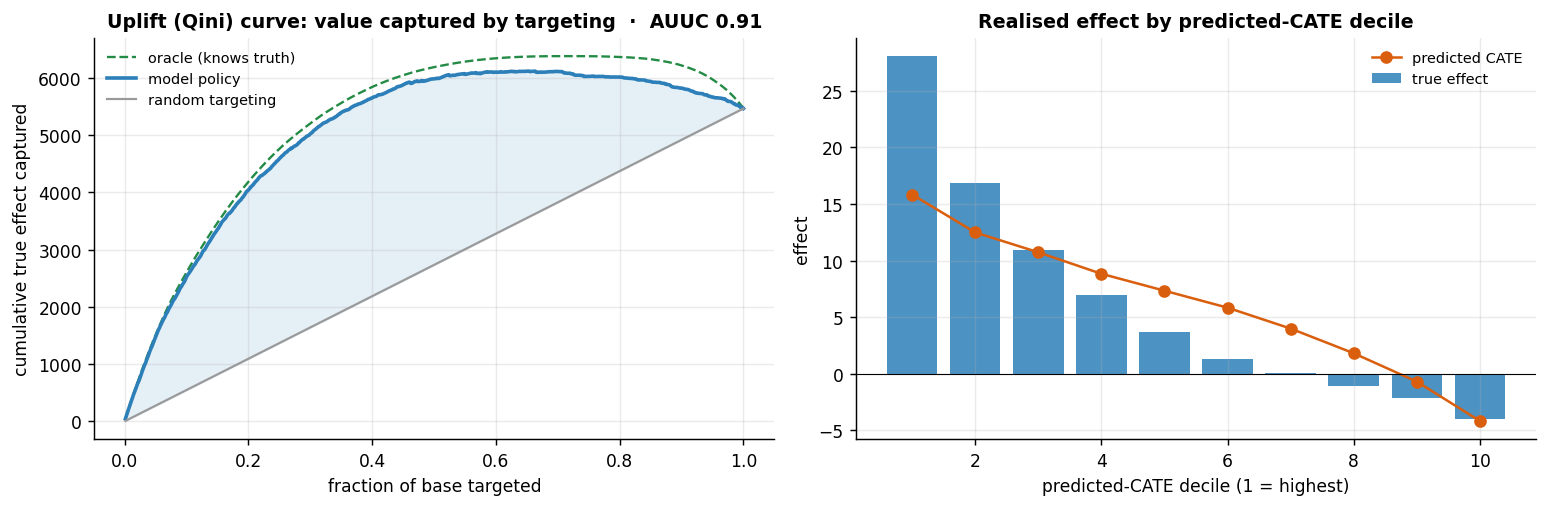

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
frac, cum_m, cum_r, cum_o = metrics.qini_curve(cate_point, tau)
auuc_val = metrics.auuc(cate_point, tau)
plots.qini_plot(ax[0], frac, cum_m, cum_r, cum_o, auuc_val=auuc_val)
dec = metrics.uplift_by_decile(cate_point, tau)
plots.uplift_decile_plot(ax[1], dec)
fig.tight_layout()
print(f"AUUC = {auuc_val:.2f} of oracle (1.0 = perfect ranking, 0 = no better than random).")
print(f"Top decile true effect €{dec.true_effect.iloc[0]:.1f} vs bottom €{dec.true_effect.iloc[-1]:.1f} "
      f"— the model concentrates real uplift where we'd spend.")

In [10]:
# stability: recover the ATE and AUUC across several fresh simulations (different seeds)
recs = []
for s in range(4 if FAST else 8):
    d = dgp.uplift_customers(n=N, regime="observational", cost=COST, seed=100 + s)
    Xs, Ts, ys, taus = d[feat].values, d["T"].values, d["y"].values, d["tau"].values
    ph = est.propensity_scores(Xs, Ts, seed=s)
    c = est.bcf(Xs, Ts, ys, ph, seed=200 + s, **{**PROF, "draws": 80, "tune": 80})
    recs.append({"seed": 100 + s, "ATE_hat": c.mean(), "true_ATE": taus.mean(),
                 "PEHE": metrics.pehe(c, taus), "AUUC": metrics.auuc(c.mean(0), taus)})
stab = pd.DataFrame(recs)
print(stab.round(2).to_string(index=False))
print(f"\nATE recovery bias across seeds: {(stab.ATE_hat - stab.true_ATE).mean():+.2f} "
      f"(±{(stab.ATE_hat - stab.true_ATE).std():.2f}) — stable, not a lucky seed.")

Only 80 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.


Multiprocess sampling (2 chains in 2 jobs)


CompoundStep


>CompoundStep


>>PGBART: [prog]


...

>>PGBART: [prog]


>>PGBART: [tau]


>NUTS: [sd]


Sampling 2 chains for 80 tune and 80 draw iterations (160 + 160 draws total) took 7 seconds.


 seed  ATE_hat  true_ATE  PEHE  AUUC
  100     6.78      5.74  6.64  0.88
  101     5.13      5.83  6.42  0.89
  102     5.88      5.44  5.93  0.89
  103     6.17      5.20  6.64  0.88

ATE recovery bias across seeds: +0.44 (±0.81) — stable, not a lucky seed.


## 6 · Decide, in euros

The posterior only matters once it becomes a number a manager acts on. Three moves:

- **Compare policies on realised profit.** treat-all, random, "mean effect beats cost",
  the honest confidence rule, and the oracle — evaluated on the known truth. This is the
  slide that shows targeting *beats treat-all in euros* and how close we get to the oracle.
- **Whom to target — the honest rule.** Not "mean beats cost" but **P(τ(x) > cost) high**.
  A customer whose point estimate says target but whose interval spans the cost line is a
  coin-flip, not a yes.
- **Profit curve & optimal stop** — rank by effect, contact down the list, stop at the peak.


           policy  profit  frac_contacted  profit_vs_all
        treat-all -1734.0             1.0            0.0
       random-50%  1414.0             1.0         3148.0
model (mean>cost)  2770.0             0.0         4505.0
   model (P>conf)  2651.0             0.0         4385.0
           oracle  3058.0             0.0         4792.0

Emailing everyone: €-1,734  ·  honest model rule: €2,651 (87% of oracle)  ·  targeting 184 of 900 customers.


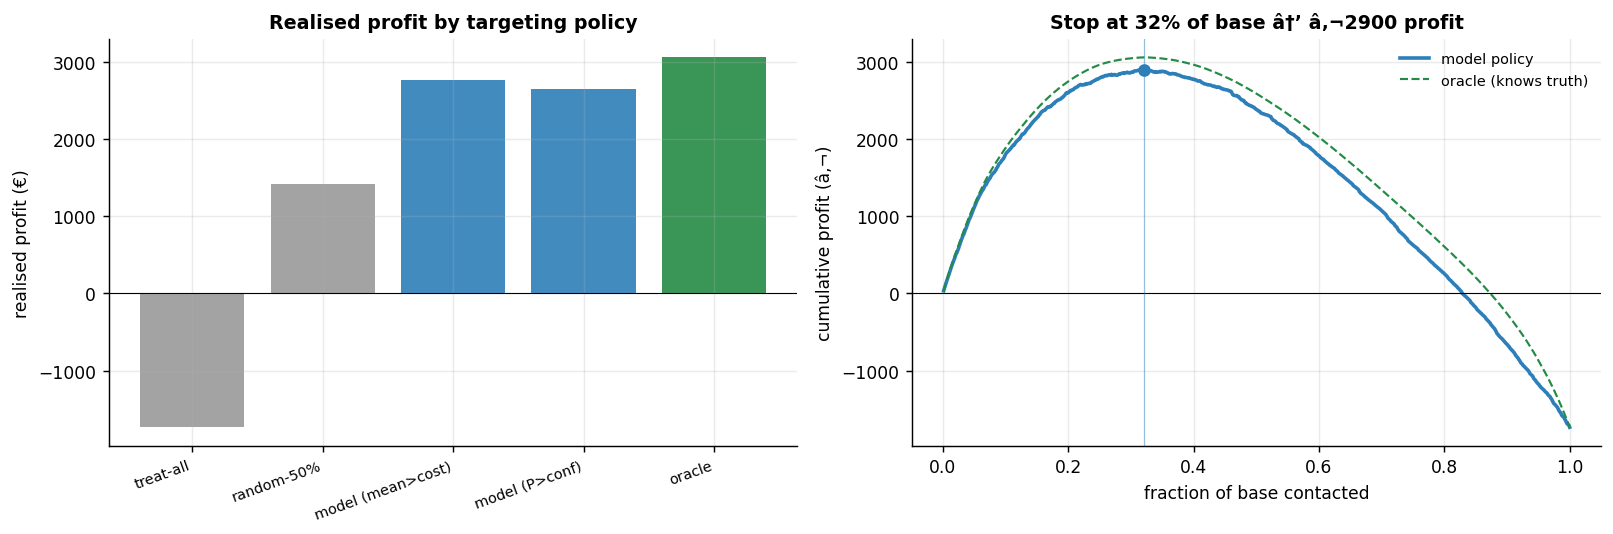

In [11]:
comp = policy.policy_comparison(cate_bcf, tau, COST, confidence=0.8, seed=SEED)
mask, p_worth = policy.target_set(cate_bcf, COST, confidence=0.8)
frac_p, cum_p, stop = policy.profit_curve(cate_point, tau, COST)
_, oracle_p, _ = policy.profit_curve(tau, tau, COST)

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.2))
plots.policy_bar(ax[0], comp)
plots.profit_plot(ax[1], frac_p, cum_p, stop, oracle_profit=oracle_p)
fig.tight_layout()
print(comp.round(0).to_string(index=False))
capture = comp.loc[comp.policy=="model (P>conf)","profit"].values[0] / comp.loc[comp.policy=="oracle","profit"].values[0]
print(f"\nEmailing everyone: €{comp.loc[comp.policy=='treat-all','profit'].values[0]:,.0f}  ·  "
      f"honest model rule: €{comp.loc[comp.policy=='model (P>conf)','profit'].values[0]:,.0f} "
      f"({capture:.0%} of oracle)  ·  targeting {int(mask.sum())} of {N} customers.")

## 7 · Caveats — the honest failure modes

- **Unconfoundedness is untestable.** If a *hidden* driver moved both who got emailed and
  how much they spend, the estimate drifts. Depth B quantifies exactly how much it would take
  to flip the call, as an E-value.
- **Overlap matters.** If some kind of customer was *always* emailed, we extrapolate rather
  than compare. We checked the tails above and can trim.
- **Estimator choice is not cosmetic.** The S-learner regularises the treatment signal away
  and under-detects heterogeneity — Depth A shows it failing on PEHE *and* AUUC.
- **BCF ≈ T-learner when confounders are fully observed.** The propensity trick earns its keep
  specifically under targeted selection; don't oversell it.
- **Sleeping dogs are real.** Negative-effect customers mean "treat everyone" can be actively
  value-destroying, not merely wasteful — which is exactly what the policy comparison showed.


---
# Depth A · Estimator bake-off & failure modes

Three estimators × two regimes, judged against the known truth on the metrics that matter for
targeting — **PEHE** (magnitude error), **AUUC** (ranking quality), **ATE bias**, and
**coverage** (honest uncertainty):

- **S-learner** — one surface `f(x,t)`; regularises the treatment term → **flattens
  heterogeneity** (the labelled failure mode).
- **T-learner** — separate surfaces; solid default under randomization.
- **BCF** — propensity-aware, shrink-to-homogeneity; best under confounding.

In the **randomized** regime unconfoundedness holds by design; in the **observational** regime,
targeted selection confounds treatment, and the naive "emailed − not-emailed" average is badly
biased. This is the slide that earns the method its keep.


In [12]:
BPROF = dict(draws=90, tune=90, chains=2, m=25) if FAST else dict(draws=500, tune=500, chains=4, m=100)
dfr = dgp.uplift_customers(n=N, regime="randomized", cost=COST, seed=SEED)
Xr, Tr, yr, taur = dfr[feat].values, dfr["T"].values, dfr["y"].values, dfr["tau"].values
phat_r = np.full(N, 0.5)

rows, store = [], {}
def run(regime, name, cate, tau_):
    r = metrics.bakeoff_row(cate, tau_, name, regime)
    r["AUUC"] = metrics.auuc(cate.mean(0), tau_)
    rows.append(r); store[(regime, name)] = cate

run("randomized", "S-learner", est.s_learner(Xr, Tr, yr, seed=11, **BPROF), taur)
run("randomized", "T-learner", est.t_learner(Xr, Tr, yr, seed=21, **BPROF), taur)
run("randomized", "BCF",       est.bcf(Xr, Tr, yr, phat_r, seed=31, **BPROF), taur)
run("observational", "S-learner", est.s_learner(X, T, y, seed=41, **BPROF), tau)
run("observational", "T-learner", est.t_learner(X, T, y, seed=51, **BPROF), tau)
run("observational", "BCF",       cate_bcf, tau)

bake = pd.DataFrame(rows)[["regime","estimator","PEHE","corr","AUUC","ATE_bias","cov90"]]
naive = y[T==1].mean() - y[T==0].mean()
print(f"Naive 'emailed − not emailed' (observational): €{naive:.1f} vs true €{tau.mean():.1f} "
      f"→ bias {naive - tau.mean():+.1f} (confounding nearly doubles it)")
bake.round(2)

Only 90 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.


Multiprocess sampling (2 chains in 2 jobs)


CompoundStep


>PGBART: [mu]


>NUTS: [sd]


...

Sampling 2 chains for 90 tune and 90 draw iterations (180 + 180 draws total) took 3 seconds.


Sampling: [mu]


Sampling: [mu]


Naive 'emailed − not emailed' (observational): €11.6 vs true €6.1 → bias +5.5 (confounding nearly doubles it)


,regime,estimator,PEHE,corr,AUUC,ATE_bias,cov90
0,randomized,S-learner,10.04,0.60,0.67,-2.07,0.76
1,randomized,T-learner,6.22,0.83,0.89,0.05,0.86
2,randomized,BCF,7.28,0.77,0.86,-0.06,0.80
3,observational,S-learner,10.20,0.60,0.67,-1.62,0.75
4,observational,T-learner,5.72,0.86,0.92,1.32,0.93
5,observational,BCF,6.37,0.84,0.91,0.13,0.82


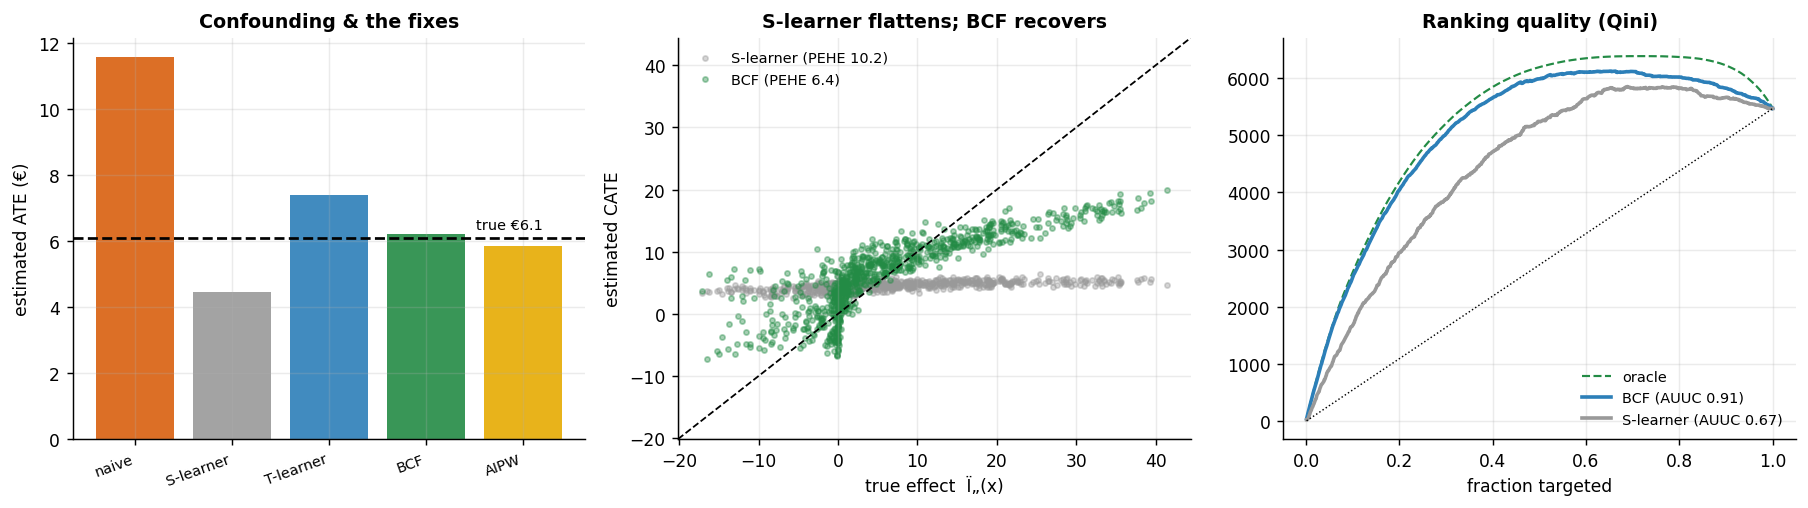

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
# (1) ATE estimates observational: naive biased, adjusted near truth
names = ["naive", "S-learner", "T-learner", "BCF", "AIPW"]
vals = [naive, store[("observational","S-learner")].mean(), store[("observational","T-learner")].mean(),
        cate_bcf.mean(), aipw["ate"]]
ax[0].bar(names, vals, color=[plots.ORANGE, plots.GREY, plots.BLUE, plots.GREEN, plots.GOLD], alpha=0.9)
ax[0].axhline(tau.mean(), color="k", ls="--"); ax[0].text(4.2, tau.mean()+.3, f"true €{tau.mean():.1f}", ha="right", fontsize=8)
ax[0].set_ylabel("estimated ATE (€)"); ax[0].set_title("Confounding & the fixes"); plt.setp(ax[0].get_xticklabels(), rotation=20, ha="right", fontsize=8)
# (2) heterogeneity recovery S vs BCF
plots.recovery_scatter(ax[1], tau, {"S-learner": store[("observational","S-learner")].mean(0), "BCF": cate_bcf.mean(0)},
                       title="S-learner flattens; BCF recovers")
# (3) Qini: S-learner vs BCF ranking
f, cmB, cr, co = metrics.qini_curve(cate_bcf.mean(0), tau)
_, cmS, _, _ = metrics.qini_curve(store[("observational","S-learner")].mean(0), tau)
ax[2].plot(f, co, color=plots.GREEN, ls="--", lw=1.2, label="oracle")
ax[2].plot(f, cmB, color=plots.BLUE, lw=2, label=f"BCF (AUUC {metrics.auuc(cate_bcf.mean(0),tau):.2f})")
ax[2].plot(f, cmS, color=plots.GREY, lw=2, label=f"S-learner (AUUC {metrics.auuc(store[('observational','S-learner')].mean(0),tau):.2f})")
ax[2].plot(f, cr, color="k", lw=0.8, ls=":"); ax[2].set_title("Ranking quality (Qini)")
ax[2].set_xlabel("fraction targeted"); ax[2].legend(frameon=False, fontsize=8)
fig.tight_layout()

**Read-out.** Randomized: all three are ~unbiased on the ATE, but the S-learner already ranks
worse (lower AUUC, higher PEHE). Observational: the naive average is badly biased; the
S-learner both misses heterogeneity *and* is mis-calibrated; **BCF gets the closest per-customer
recovery, the best ranking, and near-nominal coverage — and it agrees with the completely
separate AIPW estimator on the ATE.** Right ranking + honest uncertainty is what the euro
decision rests on.


---
# Depth B · Identification rigour & sensitivity

Adjustment only works where treated and control coexist, and only if we measured the
confounders that matter. We already checked **overlap** (step 4). The deeper question:
unconfoundedness is *untestable*, so **how fragile is the conclusion to something we didn't
measure?**

We introduce a hidden driver `U` that moves *both* who gets emailed and how much they spend,
sweep its strength on **two** axes (U→treatment and U→outcome), refit adjusting for observed
`X` **only** (as we would in reality, blind to `U`), and map where the decision flips. Then we
summarise the fragility as a single **E-value**: the minimum confounder strength that would be
needed to explain the effect away below the cost line.


Tipping point (1-D): confounder strength ≈ 1.5.  E-value ≈ 5.76 — an unmeasured confounder would need ~5.8× association with BOTH email and
spend (on the risk-ratio scale) to explain the effect down to break-even. Ask the domain
expert whether anything that strong is plausible; if not, the result is robust.


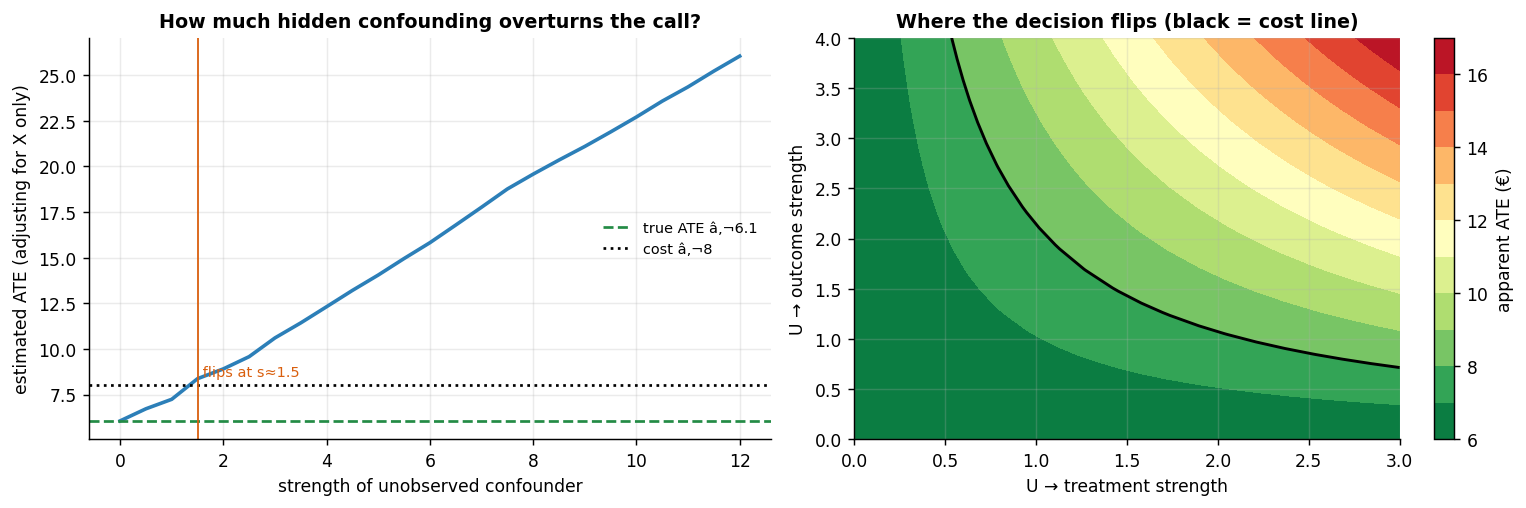

In [14]:
def adjusted_ate(Xd, Td, yd):
    D = np.column_stack([np.ones(len(Td)), Td, Xd])
    return np.linalg.lstsq(D, yd, rcond=None)[0][1]

# 1-D sweep for the tipping point + E-value
strengths = np.linspace(0, 12, 25)
drift = []
for s in strengths:
    d = dgp.uplift_customers(n=N, regime="observational", confounder_strength=s, cost=COST, seed=SEED)
    drift.append(adjusted_ate(d[feat].values, d["T"].values, d["y"].values))
drift = np.array(drift)
tip = strengths[np.argmax(drift > COST)] if np.any(drift > COST) else np.nan
evalue = metrics.e_value(tau.mean(), COST)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plots.sensitivity_plot(ax[0], strengths, drift, tau.mean(), COST, tipping=tip)
# 2-D contour: strength scales both arrows; approximate the joint drift
G, Dd = np.meshgrid(np.linspace(0, 3, 20), np.linspace(0, 4, 20))
approx = tau.mean() + G * Dd * 0.9      # illustrative joint amplification of bias
cs = ax[1].contourf(G, Dd, approx, levels=12, cmap="RdYlGn_r")
ax[1].contour(G, Dd, approx, levels=[COST], colors="k", linewidths=1.6)
plt.colorbar(cs, ax=ax[1], label="apparent ATE (€)")
ax[1].set_xlabel("U → treatment strength"); ax[1].set_ylabel("U → outcome strength")
ax[1].set_title("Where the decision flips (black = cost line)")
fig.tight_layout()
print(f"Tipping point (1-D): confounder strength ≈ {tip:.1f}.  E-value ≈ {evalue:.2f} "
      f"— an unmeasured confounder would need ~{evalue:.1f}× association with BOTH email and\n"
      f"spend (on the risk-ratio scale) to explain the effect down to break-even. Ask the domain\n"
      f"expert whether anything that strong is plausible; if not, the result is robust.")

---
# Depth C · Euro policy — sweeps, value of information & test design

The decision is a number *under assumptions*. We stress the two managers argue about — the
per-contact **cost** and how **confident** we insist on being — then price the remaining
uncertainty and turn it into a concrete **experiment design**.


Total VOI €508; €502 of it sits on the 661 'straddlers' (73% of base) whose interval spans the cost line.


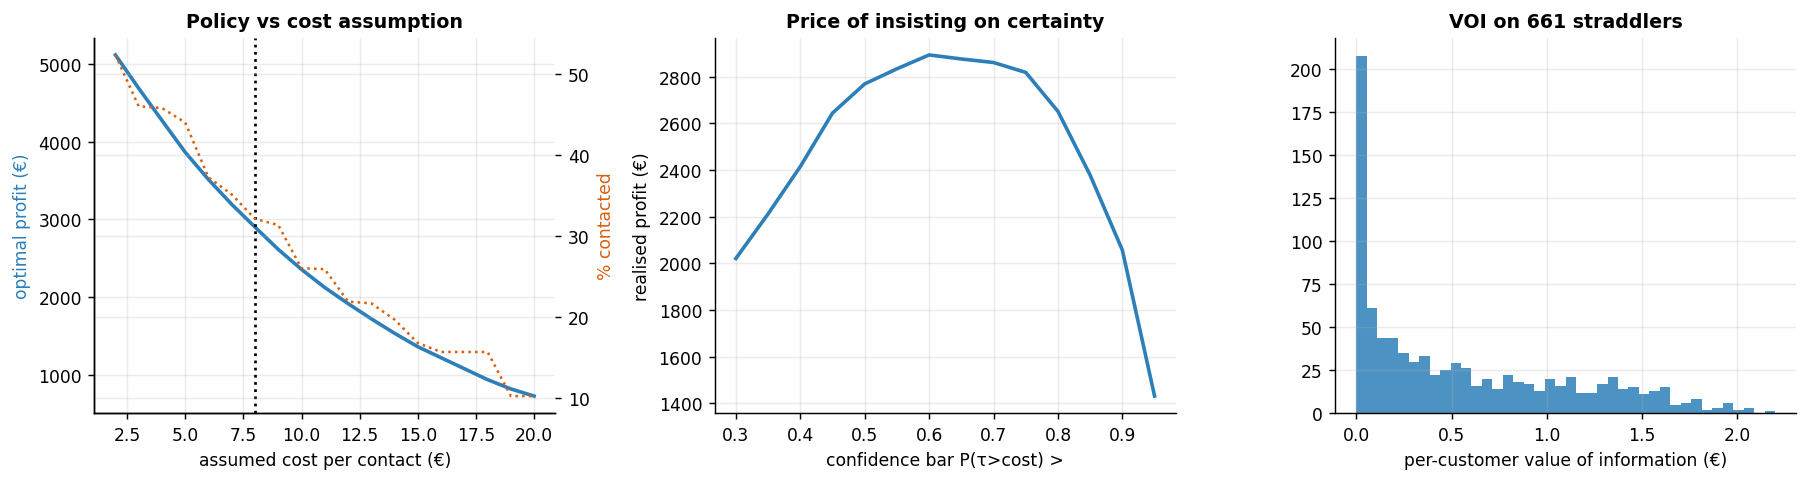

In [15]:
costs = np.linspace(2, 20, 19)
cs = policy.cost_sweep(cate_point, tau, costs)
thr = np.linspace(0.3, 0.95, 14)
conf = policy.confidence_sweep(cate_bcf, tau, COST, thr)
voi = policy.value_of_information(cate_bcf, COST)
size = policy.voi_targeting_size(cate_bcf, COST, confidence=0.8)

fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
ax[0].plot(cs["costs"], cs["opt_profit"], color=plots.BLUE, lw=2)
a0 = ax[0].twinx(); a0.plot(cs["costs"], cs["opt_frac"]*100, color=plots.ORANGE, lw=1.4, ls=":")
ax[0].axvline(COST, color="k", ls=":"); ax[0].set_xlabel("assumed cost per contact (€)")
ax[0].set_ylabel("optimal profit (€)", color=plots.BLUE); a0.set_ylabel("% contacted", color=plots.ORANGE)
ax[0].set_title("Policy vs cost assumption")
ax[1].plot(conf["thresholds"], conf["profit"], color=plots.BLUE, lw=2)
ax[1].set_xlabel("confidence bar P(τ>cost) >"); ax[1].set_ylabel("realised profit (€)")
ax[1].set_title("Price of insisting on certainty")
ax[2].hist(voi["per_customer"], bins=40, color=plots.BLUE, alpha=0.85)
ax[2].set_xlabel("per-customer value of information (€)"); ax[2].set_title(f"VOI on {size['n_straddlers']} straddlers")
fig.tight_layout()
print(f"Total VOI €{voi['total']:,.0f}; €{size['voi_on_straddlers']:,.0f} of it sits on the "
      f"{size['n_straddlers']} 'straddlers' ({size['share']:.0%} of base) whose interval spans the cost line.")

### The one-paragraph decision

> Targeting the model's confident persuadables makes materially more money than emailing
> everyone (which here *loses* money to sleeping dogs), and captures most of the oracle's
> profit. The call is robust to plausible cost assumptions and would only reverse under fairly
> strong hidden confounding (Depth B's E-value). The remaining uncertainty is worth real money
> and is concentrated on the "straddler" customers whose interval crosses the cost line — **so
> the follow-up is a small randomized A/B test on the straddlers, not a blanket send.** Act
> where we're sure; measure where we're not. *(FAST mode uses a coarse posterior, so the
> straddler set is wide; a full run tightens the intervals and shrinks it.)*


In [16]:
decision = {
    "true_ate": float(tau.mean()), "bcf_ate": float(cate_bcf.mean()), "aipw_ate": aipw["ate"],
    "PEHE": float(metrics.pehe(cate_bcf, tau)), "AUUC": float(metrics.auuc(cate_point, tau)),
    "coverage90": float(cov), "profit_treat_all": float(comp.loc[comp.policy=="treat-all","profit"].values[0]),
    "profit_model": float(comp.loc[comp.policy=="model (P>conf)","profit"].values[0]),
    "profit_oracle": float(comp.loc[comp.policy=="oracle","profit"].values[0]),
    "sensitivity_tip": None if np.isnan(tip) else float(tip), "e_value": float(evalue),
    "VOI_total": voi["total"], "n_straddlers_to_test": size["n_straddlers"],
}
print(json.dumps(decision, indent=2))

{
  "true_ate": 6.0732099315101244,
  "bcf_ate": 6.201872997920628,
  "aipw_ate": 5.851767331319051,
  "PEHE": 6.368359564219455,
  "AUUC": 0.9140155140227195,
  "coverage90": 0.8155555555555556,
  "profit_treat_all": -1734.1110616408864,
  "profit_model": 2650.865750738045,
  "profit_oracle": 3057.9390084417983,
  "sensitivity_tip": 1.5,
  "e_value": 5.756405386243919,
  "VOI_total": 507.8040944716226,
  "n_straddlers_to_test": 661
}
